# COINS vs DGDC: aggregate dual-graph degree distribution

Aggregate the dual-graph degree distribution across all cities for which both DGDC (`data/city_degrees/t10_a20/`) and COINS (`data/city_degrees_coins/a20/`) outputs exist, and plot the two aggregate degree distributions on a log-log axis.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['axes.titlepad'] = 10

In [2]:
LINES = [
    ('DGDC (a=10°)',  '../data/city_degrees/t10_a10/',       'C0'),
    ('DGDC (a=20°)',  '../data/city_degrees/t10_a20/',       'C9'),
    ('COINS (a=20°)', '../data/city_degrees_coins/a20/',     'C1'),
    ('COINS (a=45°)', '../data/city_degrees_coins/a45/',     'C3'),
]

In [3]:
file_sets = [
    {f for f in os.listdir(d) if f.endswith('.npz')}
    for _, d, _ in LINES
]
common = sorted(set.intersection(*file_sets))
for (lab, d, _), files in zip(LINES, file_sets):
    print(f'{lab:20s} {len(files):4d} cities in {d}')
print(f'\nCities common to all (used for aggregation): {len(common)}')

DGDC (a=10°)           97 cities in ../data/city_degrees/t10_a10/
DGDC (a=20°)           97 cities in ../data/city_degrees/t10_a20/
COINS (a=20°)          95 cities in ../data/city_degrees_coins/a20/
COINS (a=45°)          95 cities in ../data/city_degrees_coins/a45/

Cities common to all (used for aggregation): 95


In [4]:
def aggregate(path, files):
    return np.concatenate([
        np.load(os.path.join(path, f), allow_pickle=True)['degree']
        for f in files
    ])

aggregates = []  # list of (label, deg_array, color)
for lab, d, color in LINES:
    deg = aggregate(d, common)
    aggregates.append((lab, deg, color))
    print(f'{lab:20s} {len(deg):>10,d} nodes  | mean k = {deg.mean():5.2f}  | max k = {deg.max()}')

DGDC (a=10°)          5,576,190 nodes  | mean k =  4.14  | max k = 13060
DGDC (a=20°)          4,578,519 nodes  | mean k =  3.99  | max k = 17825
COINS (a=20°)         9,744,446 nodes  | mean k =  2.62  | max k = 706
COINS (a=45°)         5,417,619 nodes  | mean k =  3.49  | max k = 678


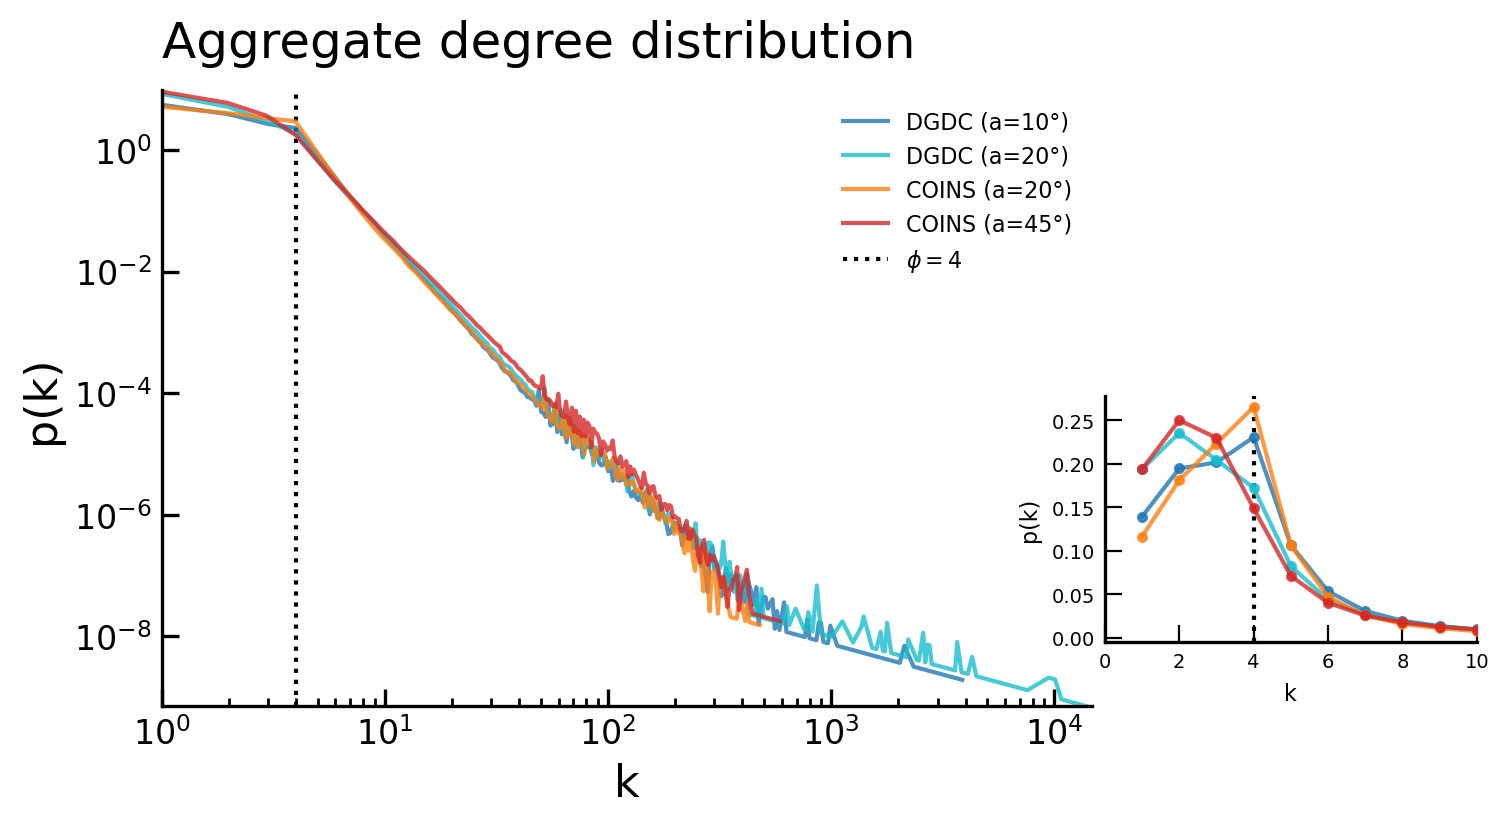

In [5]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4), dpi=200)

for lab, d, c in aggregates:
    d = d[d > 0]
    bins = np.logspace(0, np.log10(d.max()), len(np.unique(d)))
    y, x = np.histogram(d, bins=bins, density=True)
    x = x[:-1]
    x_nn = x[y != 0][:-1]
    y_nn = y[y != 0][:-1]
    ax.plot(x_nn, y_nn, alpha=0.8, zorder=2, color=c, label=lab, linewidth=1.5)

ax.yaxis.set_minor_formatter(plt.NullFormatter())
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.yaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=1.0)
ax.axvline(4, color='k', linestyle='dotted', label=r'$\phi = 4$', zorder=-1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Aggregate degree distribution', loc='left', pad=12)
ax.set_xlabel('k')
ax.set_ylabel('p(k)')
ax.legend(fontsize=8, loc='upper right', frameon=False)

# --- Inset: linear-scale zoom on k in [0, 10] ---
axins = inset_axes(ax, width="80%", height="80%", loc='lower right', borderpad=1, bbox_to_anchor=(0.95, 0.05, 0.5, 0.5), bbox_transform=ax.transAxes)

for lab, d, c in aggregates:
    d = d[d > 0]
    # linear bins over the zoom range, integer-aligned since k is discrete
    bins = np.arange(1, 12) - 0.5  # bins centered on 1,2,...,11
    y, x = np.histogram(d, bins=bins, density=True)
    centers = 0.5 * (x[:-1] + x[1:])
    axins.plot(centers, y, color=c, alpha=0.8, linewidth=1.5, marker='o', markersize=3)

axins.axvline(4, color='k', linestyle='dotted', zorder=-1)
axins.set_xlim(0, 10)
axins.set_xlabel('k', fontsize=8)
axins.set_ylabel('p(k)', fontsize=8)
axins.tick_params(labelsize=7)
axins.spines['right'].set_visible(False)
axins.spines['top'].set_visible(False)

plt.show()

In [6]:
def compute_ks(degree,min_range):
    distance = []
    for i_min in min_range:
        fit = powerlaw.Fit(degree,discrete=True,xmin=i_min)
        distance.append(fit.power_law.D)
    return np.array(distance), min_range

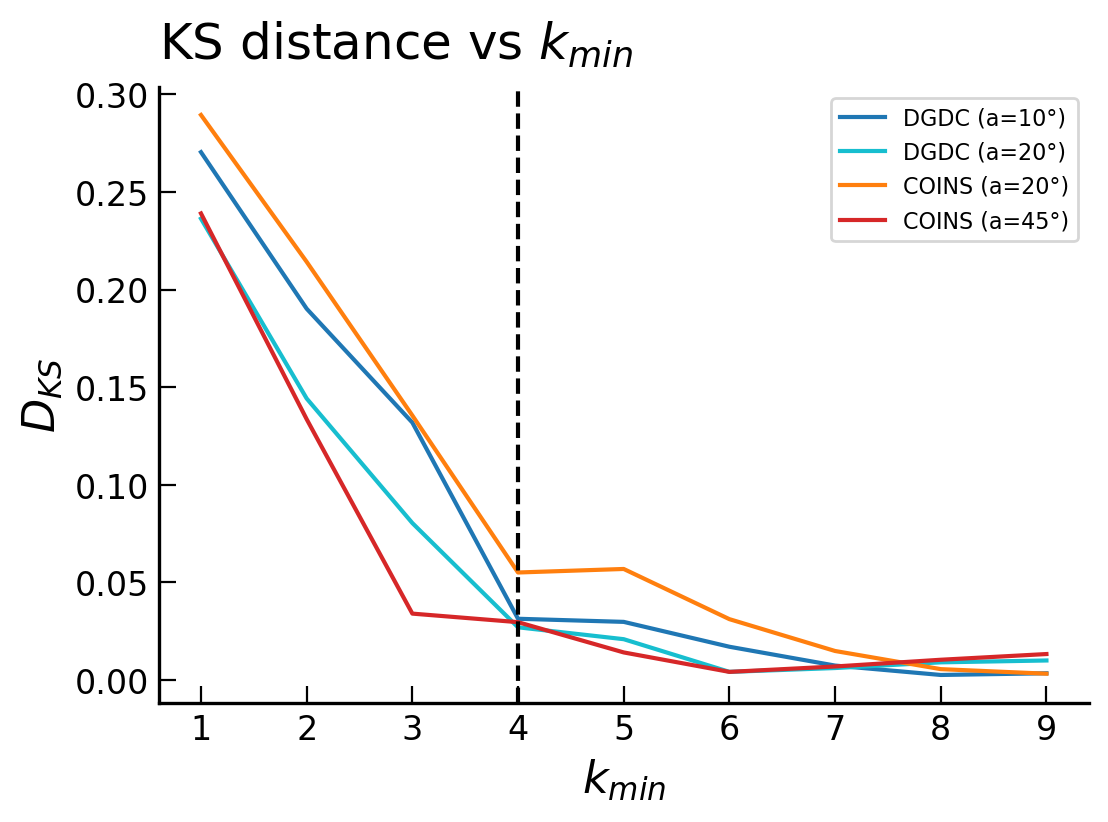

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4), dpi=200)

for lab, deg, c in aggregates:
    d = deg[deg != 0]
    ks_dist, xmins = compute_ks(d, range(1, 10))
    ax.plot(xmins, ks_dist, color=c, label=lab)

ax.set_xlabel(r'$k_{min}$')
ax.set_ylabel(r'$D_{KS}$')
ax.set_title('KS distance vs $k_{min}$', loc='left')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.axvline(x=4, color='k', linestyle='--')
plt.legend(fontsize=8)
plt.show()

# Segment Length 

In [8]:
def aggregate(path, files):
    return np.concatenate([
        np.load(os.path.join(path, f), allow_pickle=True)['length']
        for f in files
    ])

aggregate_length = []  # list of (label, length_array, color)
for lab, l, color in LINES:
    length = aggregate(l, common)
    aggregate_length.append((lab, length, color))
    print(f'{lab:20s} {len(length):>10,d} nodes  | mean l = {length.mean():5.2f}  | max l = {length.max()}')

DGDC (a=10°)          5,576,190 nodes  | mean l = 147.92  | max l = 6738531.267423441
DGDC (a=20°)          4,578,519 nodes  | mean l = 180.16  | max l = 10934266.626894975
COINS (a=20°)         9,744,446 nodes  | mean l = 84.93  | max l = 72950.39499182074
COINS (a=45°)         5,417,619 nodes  | mean l = 152.77  | max l = 85649.90311358054


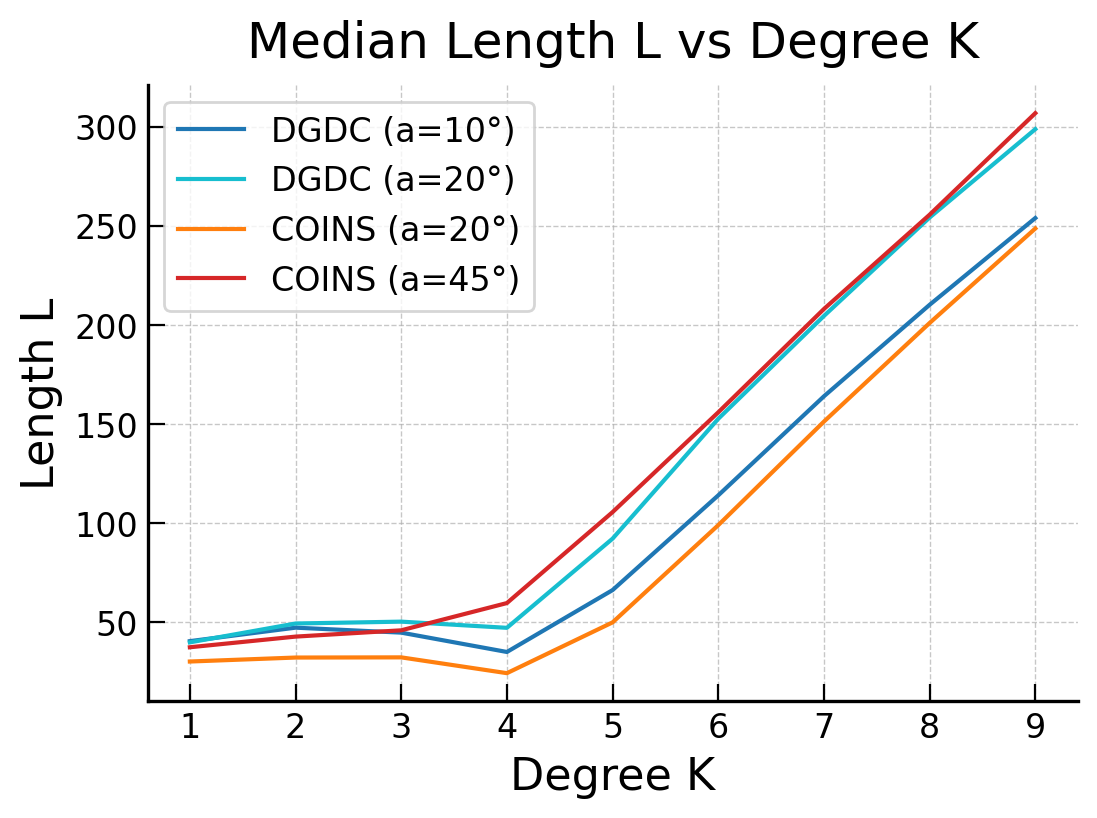

In [9]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

for degrees, length in zip(aggregates, aggregate_length):
    

    degree_I=degrees[1]
    length_I=length[1]

    lengths_by_degree_median = {}
    lengths_by_degree_mean = {}

    for k in range(1,10):
        data = length_I[degree_I == k]
        if len(data) > 0:
            lengths_by_degree_median[k] = np.median(data)


    ax.plot(list(lengths_by_degree_median.keys()), list(lengths_by_degree_median.values()), marker=None, label=length[0], color=length[2])

ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_xlabel('Degree K')
ax.set_ylabel('Length L')
ax.set_title('Median Length L vs Degree K')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend()
plt.show()

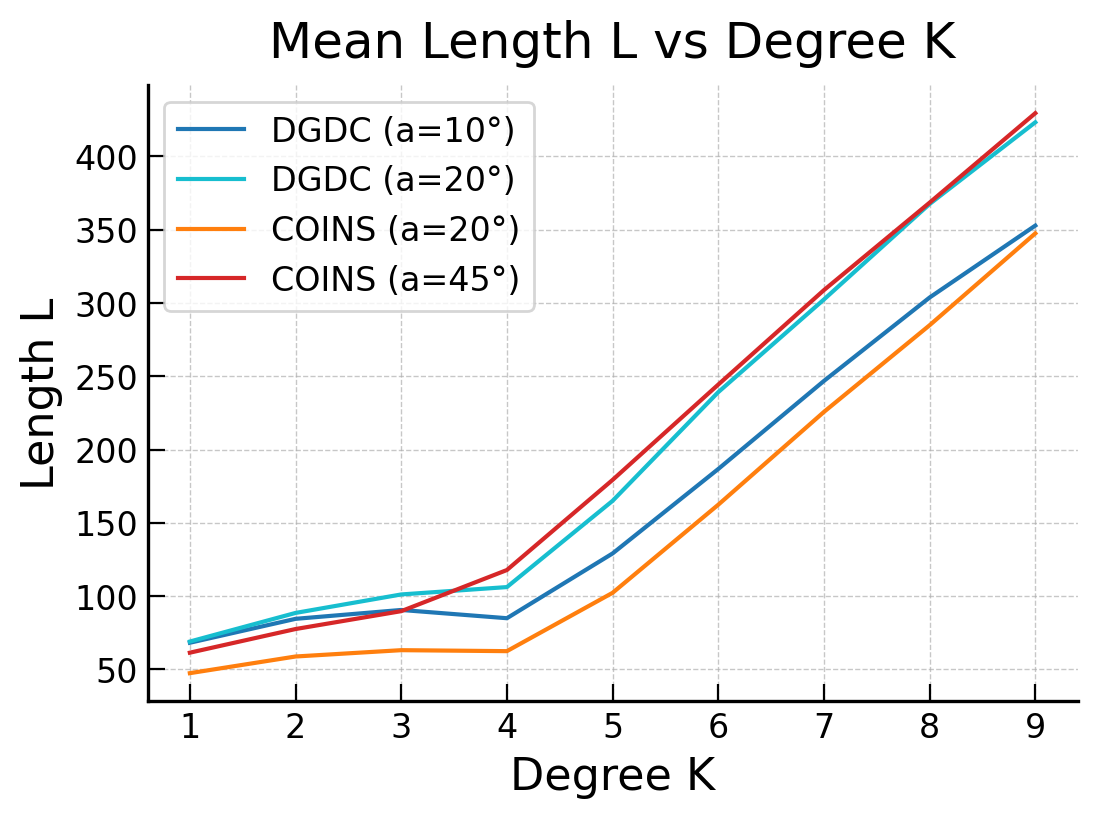

In [10]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

for degrees, length in zip(aggregates, aggregate_length):

    degree_I=degrees[1]
    length_I=length[1]

    lengths_by_degree_median = {}
    lengths_by_degree_mean = {}

    for k in range(1,10):
        data = length_I[degree_I == k]
        if len(data) > 0:
            lengths_by_degree_mean[k] = np.mean(data)

    ax.plot(list(lengths_by_degree_mean.keys()), list(lengths_by_degree_mean.values()), marker=None, label=length[0], color=length[2])


ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_xlabel('Degree K')
ax.set_ylabel('Length L')
ax.set_title('Mean Length L vs Degree K')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend()
plt.show()

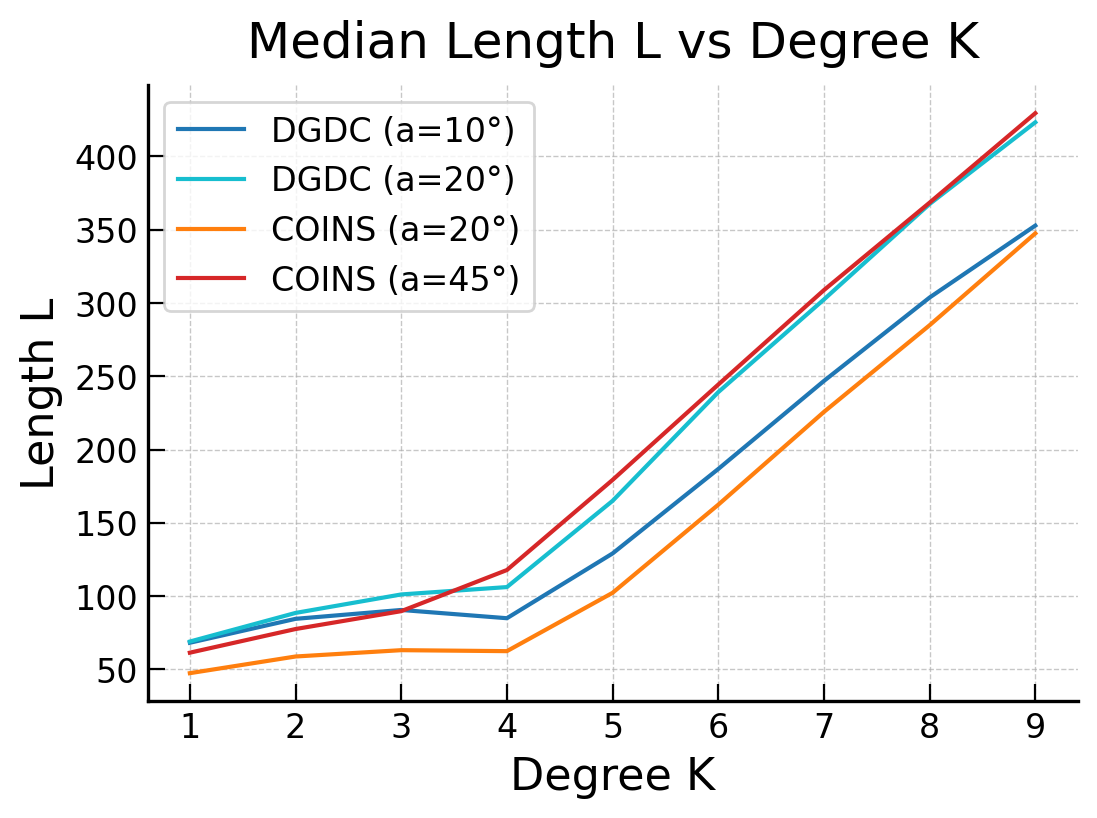

In [15]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

for degrees, length in zip(aggregates, aggregate_length):

    degree_I=degrees[1]
    length_I=length[1]

    lengths_by_degree_median = {}
    lengths_by_degree_mean = {}

    for k in range(1,10):
        data = length_I[degree_I == k]
        if len(data) > 0:
            lengths_by_degree_mean[k] = np.mean(data)

    ax.plot(list(lengths_by_degree_mean.keys()), list(lengths_by_degree_mean.values()), marker=None, label=length[0], color=length[2])


ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_xlabel('Degree K')
ax.set_ylabel('Length L')
ax.set_title('Median Length L vs Degree K')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend()
plt.show()